In [46]:
from langgraph.graph import StateGraph, START,END 
from langchain_google_genai import ChatGoogleGenerativeAI
from typing import TypedDict
from dotenv import load_dotenv
from pydantic import BaseModel,Field

In [47]:
load_dotenv()
llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash")

In [48]:
class evalstructue(BaseModel):
    feedback: str = Field(description="Detailed feedback on essay")
    score: int = Field(description="score on scale of 1-10",ge=0,le=10)

In [49]:
struct_model = llm.with_structured_output(evalstructue)

In [50]:
class LLMstate(TypedDict):
    essay: str

    COTFeedback: str
    COTScore: int

    DOAFeedback: str
    DOAScore: int

    LanguageFeedback: str
    LanguageScore: int

    FinalFeedback: str
    FinalScore: int

In [51]:
graph =StateGraph(LLMstate)

In [52]:
def calculateCOT(state: LLMstate):

    essay = state["essay"]


    prompt = f"Return a dictionary with keys COTfeedback and COTscore where COTfeedback -> Text feedback on essay on basis of clarity of thought of the essay and COTscore -> Score on scale from 1-10 on basis of clarity of thought of essay. the essay is:{essay}"

    result = struct_model.invoke(prompt)
    return {"COTFeedback": result.feedback, "COTScore": result.score}
    

In [53]:
def calculateDOA(state: LLMstate):

    essay = state["essay"]


    prompt = f"Return a dictionary with Text feedback on essay on depth of analysis of thought of the essay and Score on scale from 1-10 on basis of depth of analysis of essay. the essay is:{essay}"

    result = struct_model.invoke(prompt)
    return {"DOAFeedback": result.feedback, "DOAScore": result.score}

In [54]:
def calculateLang(state: LLMstate):

    essay = state["essay"]


    prompt = f"Return a dictionary with Text feedback on essay on basis of language of the essay and Score on scale from 1-10 on basis of language of essay. the essay is:{essay}"

    result = struct_model.invoke(prompt)
    return {"LanguageFeedback": result.feedback, "LanguageScore": result.score}

In [55]:
def calculatefinal(state: LLMstate):
    state["FinalScore"] = (state["COTScore"]+state["DOAScore"]+state["LanguageScore"])/3

    COAfeedback = state["COTFeedback"]
    DOAfeedback = state["DOAFeedback"]
    Languagefeedback = state["LanguageFeedback"]
    
    prompt = f"analyze and summarize the 3 feedbacks: {COAfeedback}{DOAfeedback}{Languagefeedback}"
    
    state["FinalFeedback"] = llm.invoke(prompt).content
    
    return state

In [56]:
graph.add_node("calculateCOT",calculateCOT)
graph.add_node("calculateDOA",calculateDOA)
graph.add_node("calculateLang",calculateLang)
graph.add_node("calculatefinal",calculatefinal)

In [57]:
graph.add_edge(START,"calculateCOT")
graph.add_edge(START,"calculateDOA")
graph.add_edge(START,"calculateLang")
graph.add_edge("calculateCOT","calculatefinal")
graph.add_edge("calculateDOA","calculatefinal")
graph.add_edge("calculateLang","calculatefinal")
graph.add_edge("calculatefinal",END)

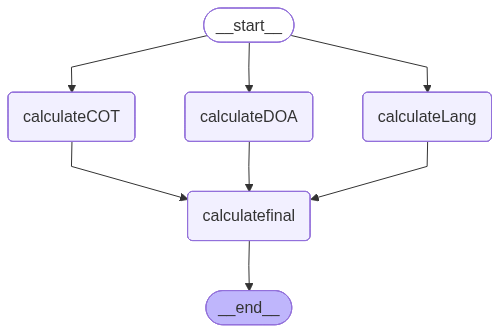

In [58]:
workflow = graph.compile()
workflow

In [60]:
initial_state = {"essay":"""The Importance of Daily Exercise"

Introduction: Maintaining a daily exercise routine is essential for a healthy lifestyle, offering both physical and mental benefits. Regular activity strengthens the heart, improves muscle tone, and releases endorphins that boost mood. Therefore, incorporating even thirty minutes of movement into one's day is a critical investment in long-term well-being. 

Body Paragraph: Physically, exercise helps regulate weight and reduces the risk of chronic diseases such as diabetes and hypertension. Studies show that consistent aerobic activity improves cardiovascular efficiency, allowing the body to function more effectively. Additionally, strength training builds bone density, which is crucial for aging populations.

Conclusion: In summary, daily exercise is not just about appearance but about sustaining overall health. By prioritizing physical activity, individuals can enhance their quality of life and prevent future medical issues. Making exercise a habit is one of the most effective steps toward a healthier, happier life"""}

final_state = workflow.invoke(initial_state)


In [61]:
print(final_state)

{'essay': 'The Importance of Daily Exercise"\n\nIntroduction: Maintaining a daily exercise routine is essential for a healthy lifestyle, offering both physical and mental benefits. Regular activity strengthens the heart, improves muscle tone, and releases endorphins that boost mood. Therefore, incorporating even thirty minutes of movement into one\'s day is a critical investment in long-term well-being. \n\nBody Paragraph: Physically, exercise helps regulate weight and reduces the risk of chronic diseases such as diabetes and hypertension. Studies show that consistent aerobic activity improves cardiovascular efficiency, allowing the body to function more effectively. Additionally, strength training builds bone density, which is crucial for aging populations.\n\nConclusion: In summary, daily exercise is not just about appearance but about sustaining overall health. By prioritizing physical activity, individuals can enhance their quality of life and prevent future medical issues. Making 